In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

In [11]:
with open("kanban_jira_completo.json", "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)

In [12]:
df.fillna({'SubTarefa_Key': 'Sem Subtarefa', 
           'Resumo_SubTarefa': 'Sem Subtarefa', 
           'Status_SubTarefa': 'Sem Subtarefa'}, inplace=True)

df['Criado_Tarefa_Pai'] = pd.to_datetime(df['Criado_Tarefa_Pai'], unit='ms')
df['Atualizado_Tarefa_Pai'] = pd.to_datetime(df['Atualizado_Tarefa_Pai'], unit='ms')

df.head()

,Tarefa_Pai,Resumo_Tarefa_Pai,Chave_Tarefa_Pai,Criado_Tarefa_Pai,Atualizado_Tarefa_Pai,Status_Tarefa_Pai,SubTarefa_Key,Resumo_SubTarefa,Status_SubTarefa,Criado_SubTarefa,Atualizado_SubTarefa,Dias_para_Atualizar_Pai,Dias_para_Atualizar_Sub
0,MTE-3354,[INCOGNITO] Recomendações GPON 360,MTE-3354,2025-07-29 16:17:29.109,2025-08-06 17:37:20.344,Tarefas pendentes,Sem Subtarefa,Sem Subtarefa,Sem Subtarefa,None,None,8,None
1,MTE-3352,[MELHORIA] Ingest base incógnito,MTE-3352,2025-07-29 15:52:01.087,2025-08-06 17:37:09.002,Tarefas pendentes,Sem Subtarefa,Sem Subtarefa,Sem Subtarefa,None,None,8,None
2,MTE-3391,[GPON] Incluir recomendação para o cliente GP...,MTE-3391,2025-08-06 12:01:42.508,2025-08-06 17:36:53.839,Tarefas pendentes,Sem Subtarefa,Sem Subtarefa,Sem Subtarefa,None,None,0,None
3,MTE-3389,[GPON] Incluir recomendação para o cliente GP...,MTE-3389,2025-08-06 12:00:19.498,2025-08-06 17:36:40.414,Tarefas pendentes,Sem Subtarefa,Sem Subtarefa,Sem Subtarefa,None,None,0,None
4,MTE-3384,[GPON] Incluir a recomendação de MESH para o ...,MTE-3384,2025-08-06 11:55:35.567,2025-08-06 17:35:30.584,Tarefas pendentes,Sem Subtarefa,Sem Subtarefa,Sem Subtarefa,None,None,0,None


C:\Users\F159446\AppData\Local\Temp\ipykernel_14636\3755389495.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=status_counts.index, y=status_counts.values, palette="Set2")


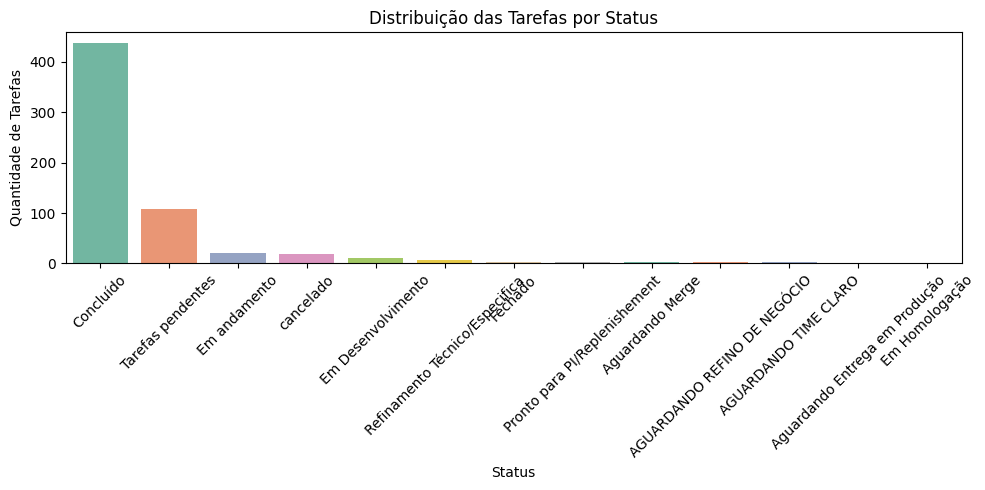

In [13]:
status_pai = df[['Chave_Tarefa_Pai', 'Status_Tarefa_Pai']].drop_duplicates()
status_counts = status_pai['Status_Tarefa_Pai'].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=status_counts.index, y=status_counts.values, palette="Set2")
plt.xticks(rotation=45)
plt.title("Distribuição das Tarefas por Status")
plt.ylabel("Quantidade de Tarefas")
plt.xlabel("Status")
plt.tight_layout()
plt.show()

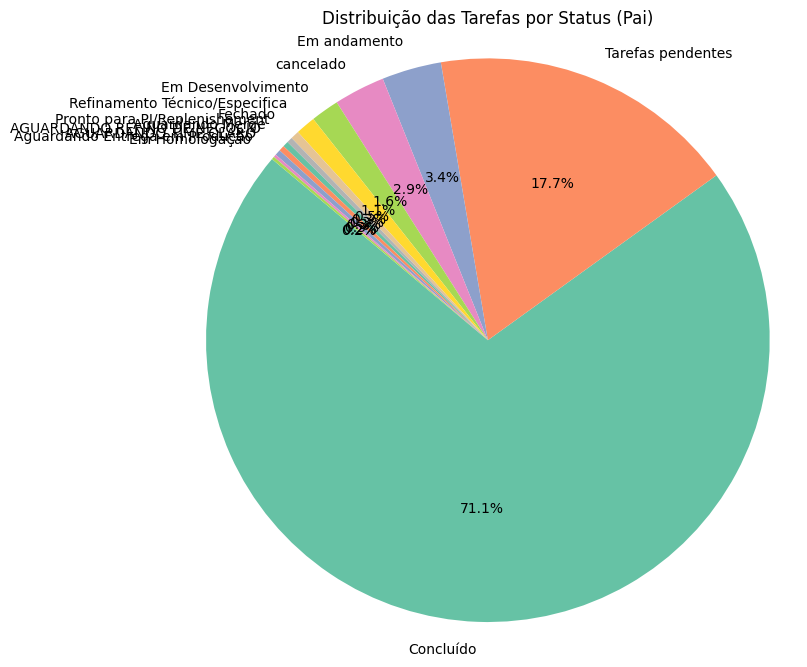

In [14]:
status_pai = df[['Chave_Tarefa_Pai', 'Status_Tarefa_Pai']].drop_duplicates()
status_counts = status_pai['Status_Tarefa_Pai'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("Set2"))
plt.title("Distribuição das Tarefas por Status (Pai)")
plt.axis('equal')  # Deixa o gráfico como círculo
plt.show()


C:\Users\F159446\AppData\Local\Temp\ipykernel_14636\1549432180.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=status_sub.index, y=status_sub.values, palette="Set3")


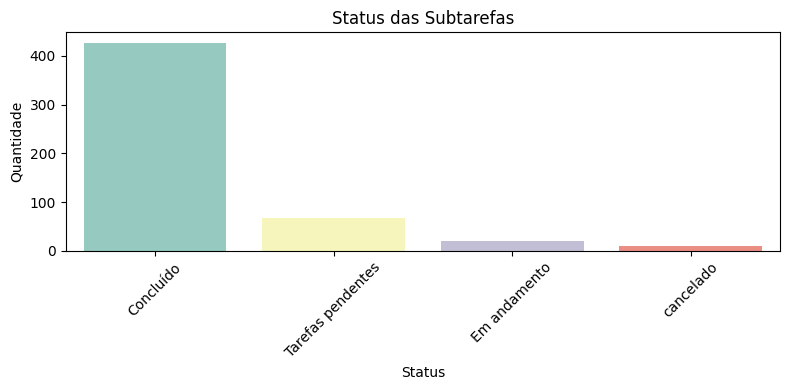

In [15]:
status_sub = df[df['SubTarefa_Key'] != 'Sem Subtarefa']['Status_SubTarefa'].value_counts()

plt.figure(figsize=(8, 4))
sns.barplot(x=status_sub.index, y=status_sub.values, palette="Set3")
plt.title("Status das Subtarefas")
plt.ylabel("Quantidade")
plt.xlabel("Status")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

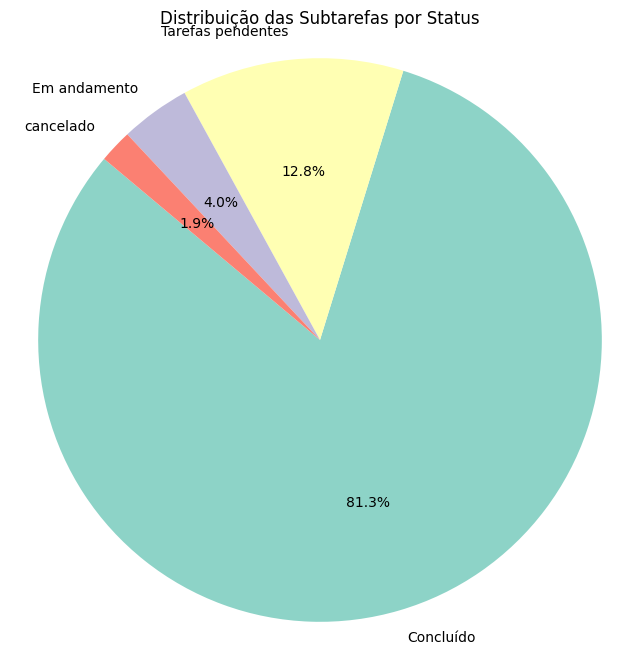

In [16]:
status_sub = df[df['SubTarefa_Key'] != 'Sem Subtarefa']['Status_SubTarefa'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(status_sub.values, labels=status_sub.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("Set3"))
plt.title("Distribuição das Subtarefas por Status")
plt.axis('equal')
plt.show()


In [17]:
colunas = [
    'Tarefa_Pai', 'Resumo_Tarefa_Pai', 'Status_Tarefa_Pai',
    'SubTarefa_Key', 'Resumo_SubTarefa', 'Status_SubTarefa',
    'Dias_para_Atualizar_Pai'
]

df_tabela = df[colunas].drop_duplicates().sort_values(by='Dias_para_Atualizar_Pai', ascending=False)

import IPython.display as display
display.display(df_tabela.head(15))

,Tarefa_Pai,Resumo_Tarefa_Pai,Status_Tarefa_Pai,SubTarefa_Key,Resumo_SubTarefa,Status_SubTarefa,Dias_para_Atualizar_Pai
970,MTE-51,[US 180273][Melhoria] Implementação das Politi...,Tarefas pendentes,MTE-202,Criação/planejameneto com detalhamento das ati...,Tarefas pendentes,553
973,MTE-51,[US 180273][Melhoria] Implementação das Politi...,Tarefas pendentes,MTE-360,Acompanhar Pós Implantação,Tarefas pendentes,553
972,MTE-51,[US 180273][Melhoria] Implementação das Politi...,Tarefas pendentes,MTE-359,Abrir / Aprovar RDM,Tarefas pendentes,553
971,MTE-51,[US 180273][Melhoria] Implementação das Politi...,Tarefas pendentes,MTE-358,Criar PIT,Tarefas pendentes,553
654,MTE-814,[MELHORIA] Desenho de solução para direcionar ...,Tarefas pendentes,Sem Subtarefa,Sem Subtarefa,Sem Subtarefa,452
655,MTE-864,[INCOGNITO] requisito de negocio,Tarefas pendentes,Sem Subtarefa,Sem Subtarefa,Sem Subtarefa,441
974,MTE-813,[MELHORIA] Criar uma API para recomendação (AP...,Tarefas pendentes,Sem Subtarefa,Sem Subtarefa,Sem Subtarefa,387
468,MTE-1442,Testes,cancelado,Sem Subtarefa,Sem Subtarefa,Sem Subtarefa,332
469,MTE-1441,Desenvolvimento no motor,cancelado,Sem Subtarefa,Sem Subtarefa,Sem Subtarefa,332
981,MTE-1277,[BEEGOL] - Recomendação de VT por Baixa Veloci...,Concluído,MTE-1635,Criação do Swagger no APIGEE p/ API Baixa Velo...,Concluído,292


In [18]:
df_maiores_atrasos = df_tabela[df_tabela['Dias_para_Atualizar_Pai'] > 60]
print("Tarefas com mais de 60 dias sem atualização:")
display.display(df_maiores_atrasos[['Tarefa_Pai', 'Resumo_Tarefa_Pai', 'Dias_para_Atualizar_Pai']])

Tarefas com mais de 60 dias sem atualização:


,Tarefa_Pai,Resumo_Tarefa_Pai,Dias_para_Atualizar_Pai
970,MTE-51,[US 180273][Melhoria] Implementação das Politi...,553
973,MTE-51,[US 180273][Melhoria] Implementação das Politi...,553
972,MTE-51,[US 180273][Melhoria] Implementação das Politi...,553
971,MTE-51,[US 180273][Melhoria] Implementação das Politi...,553
654,MTE-814,[MELHORIA] Desenho de solução para direcionar ...,452
...,...,...,...
400,MTE-2980,Apoio Teste Beegol (Baixa de Velocidade) - Solar,61
339,MTE-3027,[Recomendação] Criação do log de recomendação ...,61
340,MTE-3027,[Recomendação] Criação do log de recomendação ...,61
337,MTE-3027,[Recomendação] Criação do log de recomendação ...,61
